# Machine Learning Safety – Exercise Sheet 3

## Fundamentals and CARLA Baseline Models

**Name:** Spoorthi Bhandare  
**Exercise:** 3  
**Topic:** Training and Evaluation of Binary Classifiers

## Overview

This exercise consists of the following parts:

- **Exercise 3.4:** Dataset Exploration
- **Exercise 3.5:** Train Three Binary Classifiers
- **Exercise 3.6:** Evaluation
- **Exercise 3.7:** ODD Gap Analysis

The CARLA dataset contains forward-facing camera images collected under clear-weather and daytime conditions. Each image is annotated with three binary labels:

- Traffic light present
- Pedestrian present
- Vehicle present

Three separate binary classifiers are trained, one for each detection task.


# Exercise 3.4 – Dataset Exploration

In this section, the CARLA dataset is loaded and explored. We investigate the dataset size, class distributions, and representative images for different label combinations.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.path.exists("/content/drive/MyDrive/ML_Safety/train.zip"))
print(os.path.exists("/content/drive/MyDrive/ML_Safety/validation.zip"))
print(os.path.exists("/content/drive/MyDrive/ML_Safety/test.zip"))

True
True
True


In [3]:
import zipfile

train_zip = "/content/drive/MyDrive/ML_Safety/train.zip"
val_zip = "/content/drive/MyDrive/ML_Safety/validation.zip"
test_zip = "/content/drive/MyDrive/ML_Safety/test.zip"

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall("train")

with zipfile.ZipFile(val_zip, 'r') as zip_ref:
    zip_ref.extractall("validation")

with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall("test")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(os.listdir("train"))
print(os.listdir("validation"))
print(os.listdir("test"))

['train']
['validation']
['test']


# Exercise 3.4 – Dataset Exploration

In this section, the CARLA dataset is loaded and explored. We examine the number of images in the training and test splits, the class distribution for each binary label, and representative images for different label combinations.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
print("Training directory:")
print(os.listdir("train"))

print("\nValidation directory:")
print(os.listdir("validation"))

print("\nTest directory:")
print(os.listdir("test"))

Training directory:
['train']

Validation directory:
['validation']

Test directory:
['test']


In [7]:
print("Inside train/train:")
print(os.listdir("train/train"))

print("\nInside validation/validation:")
print(os.listdir("validation/validation"))

print("\nInside test/test:")
print(os.listdir("test/test"))

Inside train/train:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']

Inside validation/validation:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']

Inside test/test:
['labels.feather', 'rgb-front', 'imu.feather', 'collisions.feather', 'carla.log', 'weather.feather', 'gnss.feather', 'labels.csv', 'sim.log', 'actions.feather', 'segmentation-front', '.hydra']


In [8]:
import pandas as pd

# Load the training labels
train_labels = pd.read_csv("train/train/labels.csv")

print("Training labels:")
display(train_labels.head())

print("\nColumns:")
print(train_labels.columns.tolist())

print("\nShape:")
print(train_labels.shape)

Training labels:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538



Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Shape:
(7200, 7)


In [9]:
# Load validation and test labels
validation_labels = pd.read_csv("validation/validation/labels.csv")
test_labels = pd.read_csv("test/test/labels.csv")

print("Number of images in each split:")
print("Training:", len(train_labels))
print("Validation:", len(validation_labels))
print("Test:", len(test_labels))

Number of images in each split:
Training: 7200
Validation: 3600
Test: 3600


In [10]:
# Class distribution in the training set

print("Training class distribution:\n")

print("Traffic lights:")
print(train_labels["has_traffic_light"].value_counts())

print("\nPedestrians:")
print(train_labels["has_pedestrian"].value_counts())

print("\nVehicles:")
print(train_labels["has_vehicle"].value_counts())

Training class distribution:

Traffic lights:
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

Pedestrians:
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

Vehicles:
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


### Exercise 3.4.3 – Example Images

Display representative camera images for different label combinations and observe the visual patterns associated with traffic lights, pedestrians, and vehicles.

In [11]:
import os

rgb_path = "train/train/rgb-front"

print("Files inside rgb-front:")
print(os.listdir(rgb_path)[:20])

Files inside rgb-front:
['046440.jpg', '030340.jpg', '054350.jpg', '071820.jpg', '035940.jpg', '069040.jpg', '062640.jpg', '010270.jpg', '057580.jpg', '040220.jpg', '048730.jpg', '045890.jpg', '028630.jpg', '049150.jpg', '068780.jpg', '005070.jpg', '037560.jpg', '015640.jpg', '037850.jpg', '059620.jpg']


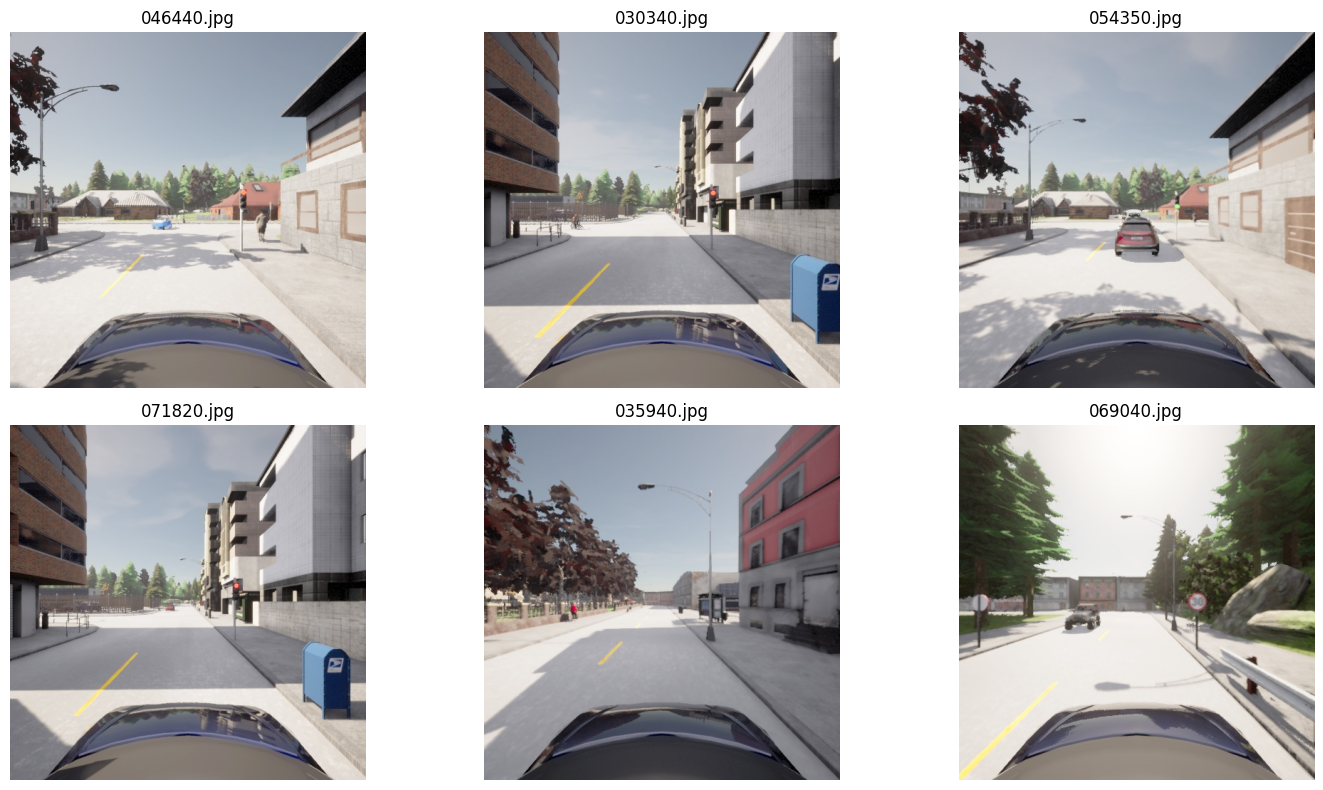

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select a few RGB camera images
image_files = os.listdir(rgb_path)[:6]

# Display the images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, filename in zip(axes.flat, image_files):
    image = Image.open(os.path.join(rgb_path, filename))
    ax.imshow(image)
    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

Exercise 3.5 – Train Three Binary Classifiers

### Exercise 3.5.1 — Model Architecture and Training Setup

Three separate binary classifiers were trained for pedestrian, traffic-light, and vehicle detection.

Each classifier uses a pre-trained ResNet18 model. The final fully connected layer was replaced with a single output neuron for binary classification.

Training setup:
- Backbone: Pre-trained ResNet18
- Output layer: 1 neuron
- Loss function: Binary Cross Entropy with Logits Loss (BCEWithLogitsLoss)
- Optimizer: Adam
- Learning rate: 0.0001
- Number of epochs: 5
- Hardware: CUDA GPU

In [13]:
# Exercise 3.5.1 – Imports and configuration

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [14]:
# Exercise 3.5.1 - Prepare dataset

import os
import pandas as pd
from PIL import Image

# Paths
train_img_path = "train/train/rgb-front"
val_img_path = "validation/validation/rgb-front"
test_img_path = "test/test/rgb-front"

train_label_path = "train/train/labels.csv"
val_label_path = "validation/validation/labels.csv"
test_label_path = "test/test/labels.csv"

# Load labels
train_labels = pd.read_csv(train_label_path)
val_labels = pd.read_csv(val_label_path)
test_labels = pd.read_csv(test_label_path)

# Get image files
train_images = sorted([
    os.path.join(train_img_path, f)
    for f in os.listdir(train_img_path)
    if f.endswith(".jpg")
])

val_images = sorted([
    os.path.join(val_img_path, f)
    for f in os.listdir(val_img_path)
    if f.endswith(".jpg")
])

test_images = sorted([
    os.path.join(test_img_path, f)
    for f in os.listdir(test_img_path)
    if f.endswith(".jpg")
])

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

print("\nTraining labels:", len(train_labels))
print("Validation labels:", len(val_labels))
print("Test labels:", len(test_labels))

Training images: 7200
Validation images: 3600
Test images: 3600

Training labels: 7200
Validation labels: 3600
Test labels: 3600


In [15]:
# Dataset class

class CarlaDataset(Dataset):
    def __init__(self, image_paths, labels, target_column, transform=None):
        self.image_paths = image_paths
        self.labels = labels[target_column].astype(float).values
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [16]:
# Image transformations

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
# Create datasets for each detection task

tasks = {
    "pedestrian": "has_pedestrian",
    "traffic_light": "has_traffic_light",
    "vehicle": "has_vehicle"
}

datasets = {}

for task_name, target_column in tasks.items():

    train_dataset = CarlaDataset(
        train_images,
        train_labels,
        target_column,
        train_transform
    )

    val_dataset = CarlaDataset(
        val_images,
        val_labels,
        target_column,
        val_test_transform
    )

    test_dataset = CarlaDataset(
        test_images,
        test_labels,
        target_column,
        val_test_transform
    )

    datasets[task_name] = {
        "train": train_dataset,
        "val": val_dataset,
        "test": test_dataset
    }

    print(
        task_name,
        "->",
        len(train_dataset),
        "train,",
        len(val_dataset),
        "validation,",
        len(test_dataset),
        "test"
    )

pedestrian -> 7200 train, 3600 validation, 3600 test
traffic_light -> 7200 train, 3600 validation, 3600 test
vehicle -> 7200 train, 3600 validation, 3600 test


In [18]:
# Create DataLoaders

batch_size = 32

loaders = {}

for task_name in tasks:

    train_loader = DataLoader(
        datasets[task_name]["train"],
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        datasets[task_name]["val"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    test_loader = DataLoader(
        datasets[task_name]["test"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    loaders[task_name] = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [19]:
# Create binary classification model

def create_model():
    model = models.resnet18(weights="DEFAULT")

    # Replace the final layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)

    return model.to(device)

In [20]:
# Training function

def train_model(model, train_loader, val_loader, epochs=5, lr=0.0001):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f}"
        )

    return history

In [21]:
# Train the three binary classifiers

models_dict = {}
histories = {}

for task_name in tasks:

    print("\n" + "="*50)
    print(f"Training {task_name} detector")
    print("="*50)

    model = create_model()

    history = train_model(
        model,
        loaders[task_name]["train"],
        loaders[task_name]["val"],
        epochs=5,
        lr=0.0001
    )

    models_dict[task_name] = model
    histories[task_name] = history


Training pedestrian detector
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Epoch 1/5 - Train Loss: 0.4666 - Val Loss: 0.6299
Epoch 2/5 - Train Loss: 0.3497 - Val Loss: 0.6940
Epoch 3/5 - Train Loss: 0.2736 - Val Loss: 0.7999
Epoch 4/5 - Train Loss: 0.2153 - Val Loss: 0.8028
Epoch 5/5 - Train Loss: 0.1759 - Val Loss: 0.8278

Training traffic_light detector
Epoch 1/5 - Train Loss: 0.1610 - Val Loss: 0.0954
Epoch 2/5 - Train Loss: 0.0713 - Val Loss: 0.0816
Epoch 3/5 - Train Loss: 0.0542 - Val Loss: 0.0700
Epoch 4/5 - Train Loss: 0.0418 - Val Loss: 0.0706
Epoch 5/5 - Train Loss: 0.0329 - Val Loss: 0.0841

Training vehicle detector
Epoch 1/5 - Train Loss: 0.3385 - Val Loss: 0.3947
Epoch 2/5 - Train Loss: 0.2002 - Val Loss: 0.3622
Epoch 3/5 - Train Loss: 0.1739 - Val Loss: 0.2631
Epoch 4/5 - Train Loss: 0.1438 - Val Loss: 0.2934
Epoch 5/5 - Train Loss: 0.1222 - Val Loss: 0.3540


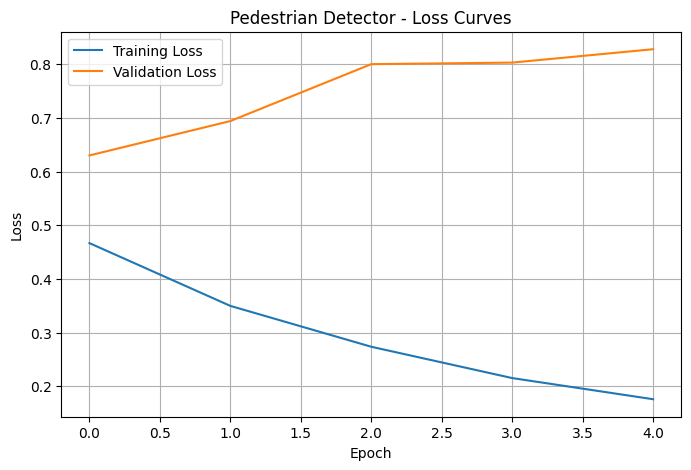

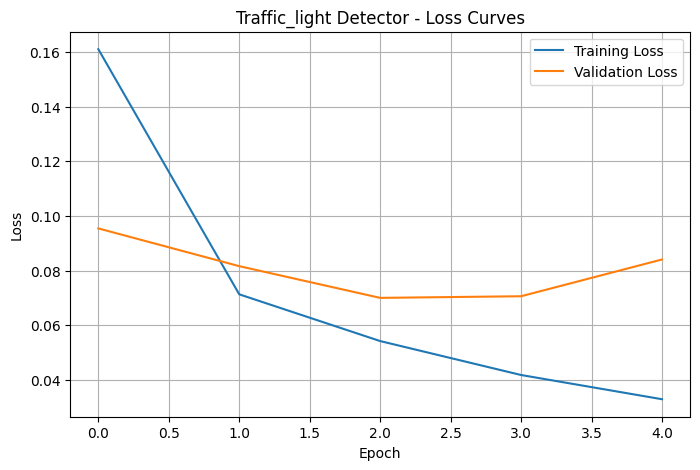

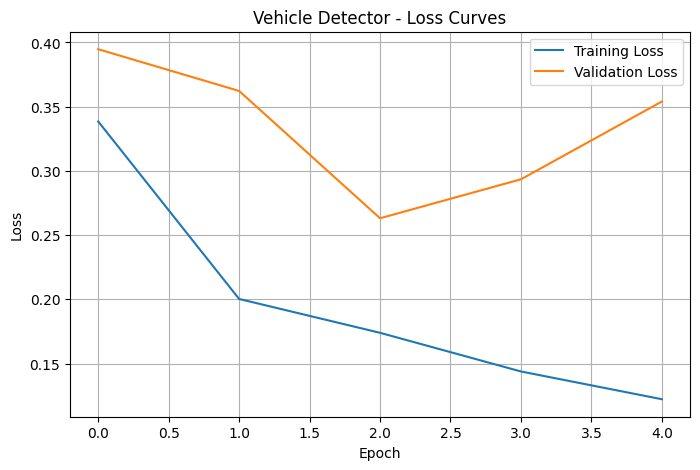

In [22]:
# Plot training and validation loss curves

for task_name, history in histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{task_name.capitalize()} Detector - Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

### Exercise 3.5.2 — Training and Validation Loss

The three models show decreasing training loss over the five epochs.

The traffic-light detector shows good convergence because both training and validation loss remain relatively low. The vehicle detector also improves during training, although the validation loss starts increasing after reaching its minimum, indicating some overfitting.

The pedestrian detector shows clear overfitting. Its training loss continuously decreases, while its validation loss continuously increases. Therefore, the pedestrian model does not generalize well to the validation data.

Overall, the models learn from the training data, but the pedestrian detector shows the strongest evidence of overfitting.

### Exercise 3.5.3 — Why Train Three Separate Models?

Training three separate binary classifiers is preferable from a safety perspective because each detection task can be evaluated independently.

Separate models allow us to:
- analyse the performance and failure cases of each detection task separately,
- use task-specific evaluation metrics and safety requirements,
- identify which detector is responsible when a failure occurs,
- improve or retrain one detector without changing the other models.

This is particularly important because pedestrian detection is more safety-critical than some other detection tasks. A failure in the pedestrian detector can directly lead to a dangerous situation for a person.

In [23]:
# Exercise 3.6.1 - Evaluate the three binary classifiers

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for task_name, model in models_dict.items():

    print("=" * 50)
    print(f"Evaluating {task_name} detector")
    print("=" * 50)

    model.eval()

    all_labels = []
    all_predictions = []

    # Test data
    test_loader = loaders[task_name]["test"]

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Convert model output to binary prediction
            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy().flatten())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)

    print(f"Accuracy :  {accuracy:.4f}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print()

Evaluating pedestrian detector
Accuracy :  0.7719
Precision:  0.4059
Recall:     0.3513
F1-score:   0.3766

Evaluating traffic_light detector
Accuracy :  0.9369
Precision:  0.9334
Recall:     0.9822
F1-score:   0.9572

Evaluating vehicle detector
Accuracy :  0.8875
Precision:  0.9509
Recall:     0.8963
F1-score:   0.9228



The pedestrian detector performs worst. It has the lowest accuracy (0.7719), precision (0.4059), recall (0.3513), and F1-score (0.3766). One possible reason is that pedestrians may be more difficult to detect because they can be smaller in the camera images, appear at different distances and positions, and may be visually similar to the background. The training results also show signs of overfitting, as the training loss decreases while the validation loss increases.

Recall is particularly important for the pedestrian and traffic-light detectors because missing a relevant object can be dangerous. A low recall means that some pedestrians or traffic lights may not be detected at all. For the vehicle detector, recall is also important because failing to detect a vehicle could create a safety risk. However, precision is also relevant because too many false positives could lead to unnecessary or incorrect safety actions. In general, for safety-critical object detection, recall is especially important because false negatives can have serious consequences.

### Exercise 3.6 — Evaluation Results

The trained models were evaluated on the test split using accuracy, precision, recall, and F1-score.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Pedestrian | 0.7719 | 0.4059 | 0.3513 | 0.3766 |
| Traffic Light | 0.9369 | 0.9334 | 0.9822 | 0.9572 |
| Vehicle | 0.8875 | 0.9509 | 0.8963 | 0.9228 |

#### Which model performs worst?

The pedestrian detector performs worst overall. It has the lowest precision, recall, and F1-score. This is consistent with the loss curves, which showed strong overfitting.

The pedestrian detector has a particularly low recall of 0.3513, meaning that many pedestrians are not detected correctly.

#### Which metric matters most from a safety perspective?

Recall is particularly important for pedestrian and vehicle detection because a false negative means that an existing object is missed. Missing a pedestrian or vehicle can lead to an unsafe decision.

For traffic-light detection, both precision and recall are important because both missed detections and incorrect detections can lead to unsafe decisions. In general, recall is important when the safety concern is failing to detect an actual traffic light.

## Exercise 3.7 — ODD Gap Analysis

### 1. Conditions covered by the training data

The training dataset contains forward-facing camera images collected in clear weather and daytime conditions.

The training data therefore covers:
- Clear weather and dry-road conditions
- Daytime lighting
- Forward-facing camera images
- Urban driving scenes represented in the CARLA dataset
- Pedestrian, traffic-light, and vehicle detection tasks

### 2. ODD dimensions not covered by the training data

Several conditions defined in the ODD are not represented in the training data.

- Rain, fog, and snow
- Night-time and low-light conditions
- Camera degradation such as dirt, mud, and glare
- Rural roads and highways
- Driving conditions above the defined speed limit of 50 km/h are not demonstrated by the available training data

The training data therefore represents only a subset of the defined ODD.

### 3. Safety implications of the ODD gap

The models may perform well under clear-weather and daytime conditions, but their performance cannot be assumed to remain reliable under conditions that are not represented in the training data.

For example, fog, rain, snow, low light, camera dirt, mud, or glare can change the input distribution and reduce perception reliability. Similarly, rural roads and highways may contain scenes that differ from the training distribution.

This is particularly important for the pedestrian detector because pedestrian detection was identified as the most safety-critical function in the previous exercise. A missed pedestrian detection could directly lead to human injury.

### 4. Identified ODD gaps

The main gaps identified are:

1. Rain, fog, and snow
2. Night-time and low-light conditions
3. Camera dirt, mud, and glare
4. Rural roads and highways
5. Lack of evidence for conditions above 50 km/h
6. Limited coverage outside clear-weather daytime urban driving

These gaps should be considered in the later safety evaluation and ODD coverage analysis.